# NF-GP Learning on Real Geospatial Data

*Make sure to have run the data processing notebook before running this one*

## Imports

In [14]:
%load_ext autoreload
%autoreload 2

In [16]:
import torch
import numpy as np
import pandas as pd

from DKL.training.main_trainer import train_joint_model
from DKL.training.extra_trainer import train_naive_gp
from DKL.utils.display import data_plotting, data_pred_new_realization,data_test_new_realization

## Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data Loading

In [3]:
df_grid = pd.read_csv('../data/df_predict.csv')
df = pd.read_csv('../data/df_valid.csv')

# Mélange aléatoire des indices
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Séparation
n_train = 5_000
df_train = df_shuffled.iloc[:n_train]
df_test = df_shuffled.iloc[n_train:(2*n_train)]

print(f"Entraînement : {len(df_train)} points")
print(f"Test : {len(df_test)} points")


X_train_np = df_train[['x', 'y']].values.astype(np.float32)  # Points d'entraînement NumPy
X_train_torch = torch.tensor(X_train_np, dtype=torch.float32).to(device)

y_train_np = df_train['sst'].values.astype(np.float32) + df_train['sst_std'].values.astype(np.float32)*np.random.randn(n_train)  # Valeurs cibles d'entraînement NumPy
y_train_torch = torch.tensor(y_train_np, dtype=torch.float32).to(device)

X_test_np = df_test[['x', 'y']].values.astype(np.float32)  # Points de test NumPy
X_test_torch = torch.tensor(X_test_np, dtype=torch.float32).to(device)
y_test_np = df_test['sst'].values.astype(np.float32)  # Valeurs cibles de test NumPy
y_test_torch = torch.tensor(y_test_np, dtype=torch.float32).to(device)

df_grid = df_grid[:n_train]
X_predict_np = df_grid[['x', 'y']].values.astype(np.float32)  # Points de grille NumPy
X_predict_torch = torch.tensor(X_predict_np, dtype=torch.float32).to(device)

common_data = {
        'X_train_np': X_train_np, # Points d'entraînement NumPy
        'X_train_torch': X_train_torch, # Points d'entraînement Torch
        'X_test_np': X_test_np, # Points de test NumPy
        'X_test_torch': X_test_torch, # Points de test Torch
        'X_predict_np': X_predict_np, # Points de prédiction NumPy
        'X_predict_torch': X_predict_torch, # Points de prédiction Torch
        'n_train_points': n_train,
    }


# Stocker les données de cette réalisation
realization = {
    'Y_train_np': y_train_np, # y aux points d'entraînement format np
    'Y_train_torch': y_train_torch, # y aux points d'entraînement format torch
    'Y_test_np': y_test_np, # y aux points de test np
    'Y_test_torch': y_test_torch, # y aux points de test torch  
   }



Entraînement : 5000 points
Test : 5000 points


## Training

In [4]:
## Hyperparameters for Normalizing Flow and Gaussian process Learning

num_epochs = 600 # Number of epochs for training
flow_learning_rate = 0.001 # Separate learning rate for flow
gp_learning_rate = 0.005 # Separate learning rate for GP/Likelihood (can be different)
num_flow_blocks = 12 # Number of blocks in the RealNVP flow model
freeze_gp_params = False # Set to True to freeze GP/Likelihood params during joint training
nouvel_entrainement = True # Set to True to start fresh training, False to resume from checkpoint
if nouvel_entrainement:
    %rm -rf ../models/*

# Train the joint model with separate learning rates
trained_flow, trained_gp, trained_likelihood, loss_history  = train_joint_model(common_data,
                                                                                realization,
                                                                                num_epochs=num_epochs, 
                                                                                flow_lr=flow_learning_rate, 
                                                                                gp_lr=gp_learning_rate,
                                                                                device = device,
                                                                                num_flow_blocks=num_flow_blocks,
                                                                                patience=10, delta = 0.001, 
                                                                                no_learn_lengthscale=freeze_gp_params)


RealNVP model created with 12 affine blocks.
MLP output layers initialized to zeros for near-identity transform.
No checkpoint found. Starting training from scratch.

Starting training...


 26%|██▌       | 153/600 [04:47<13:59,  1.88s/it]

Early Stopping triggered at epoch 154! No improvement for 10 epochs.
Training finished.
Loading best joint model from /Users/solal/Desktop/DKL/models/learned_gp_checkpoint.pth for final return...


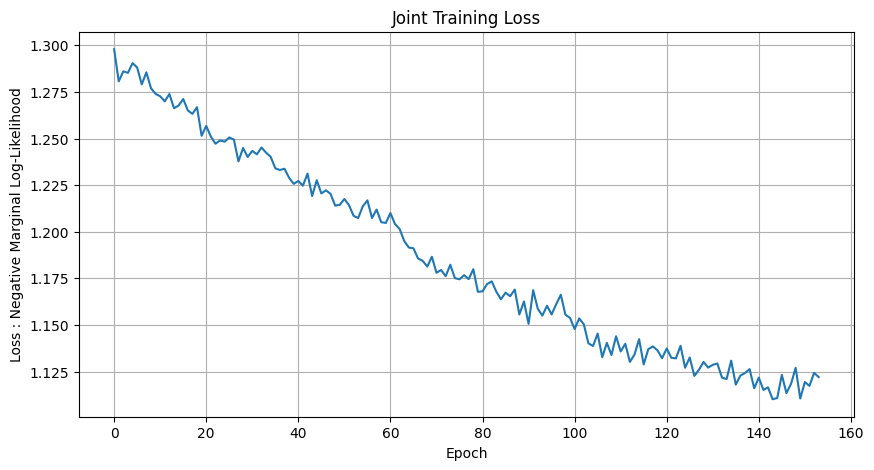

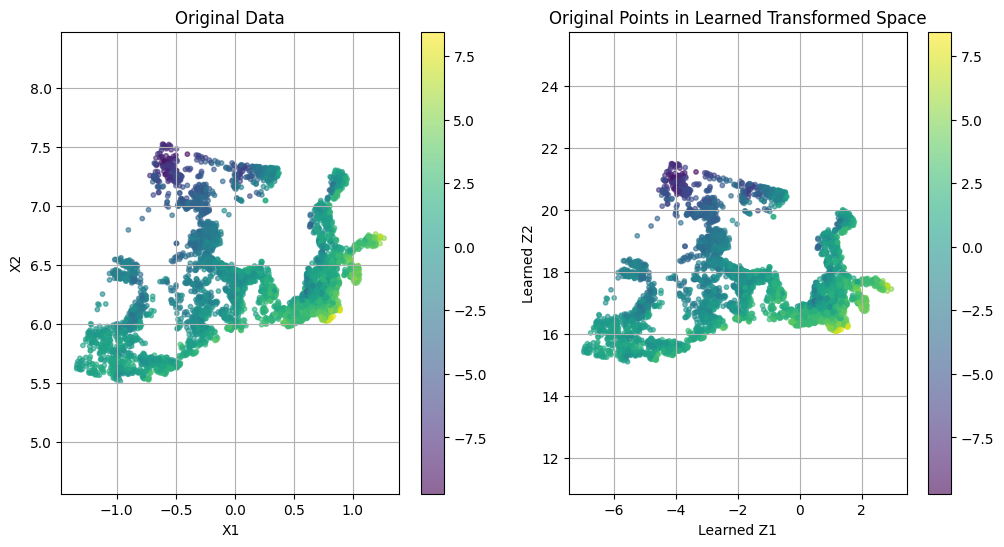

In [7]:
data_plotting(trained_flow,trained_gp,trained_likelihood,
         common_data, realization,
        loss_history)

### Entrainement des GP de comparaison

In [9]:
naive_gp_model, naive_likelihood = train_naive_gp(common_data, realization,num_epochs=600,
                                                lr=0.01, checkpoint_name='naive_gp_checkpoint.pth')


No Naive GP checkpoint found. Starting training from scratch.
Training Naive GP on original data for 600 epochs (starting at 0)...


  2%|▏         | 10/600 [00:08<08:06,  1.21it/s]

  Naive GP Epoch 10/600: Loss 1.2849, Lengthscale: [[0.6444214]], Outputscale: 0.7443, Noise: 0.6717
  Best loss detected and epoch eligible for saving.


  3%|▎         | 20/600 [00:16<07:52,  1.23it/s]

  Naive GP Epoch 20/600: Loss 1.2709, Lengthscale: [[0.59836966]], Outputscale: 0.7972, Noise: 0.6554
  Best loss detected and epoch eligible for saving.


...

  Naive GP Epoch 160/600: Loss 1.0508, Lengthscale: [[0.15383476]], Outputscale: 1.7460, Noise: 0.3370
  Best loss detected and epoch eligible for saving.


 28%|██▊       | 170/600 [02:40<07:25,  1.04s/it]

  Naive GP Epoch 170/600: Loss 1.0300, Lengthscale: [[0.13211803]], Outputscale: 1.8572, Noise: 0.3000
  Best loss detected and epoch eligible for saving.


 32%|███▏      | 190/600 [02:57<06:23,  1.07it/s]

Early Stopping triggered at epoch 191! No improvement for 10 epochs.
Naive GP training complete.
Loading best Naive GP model from /Users/solal/Desktop/DKL/models/naive_gp_checkpoint.pth for final return...


### Results Comparison


--- Testing with Existing Test Grid ---
Using the initial test grid data from generation...
Predicting and Sampling from Learned GP on test grid...


GP Predictions: 100%|██████████| 3/3 [00:00<00:00,  3.19it/s]


Predicting and Sampling from Guessed GP on test grid...


GP Predictions: 100%|██████████| 3/3 [00:33<00:00, 11.26s/it]



Calculating MSE on Initial Test Grid Data...
MSE (Learned Non-Stationary GP) vs True Test Grid (Rzn 0): 0.126323
MSE (Best Stationary GP in Original Space) vs True Test Grid (Rzn 0): 0.116828


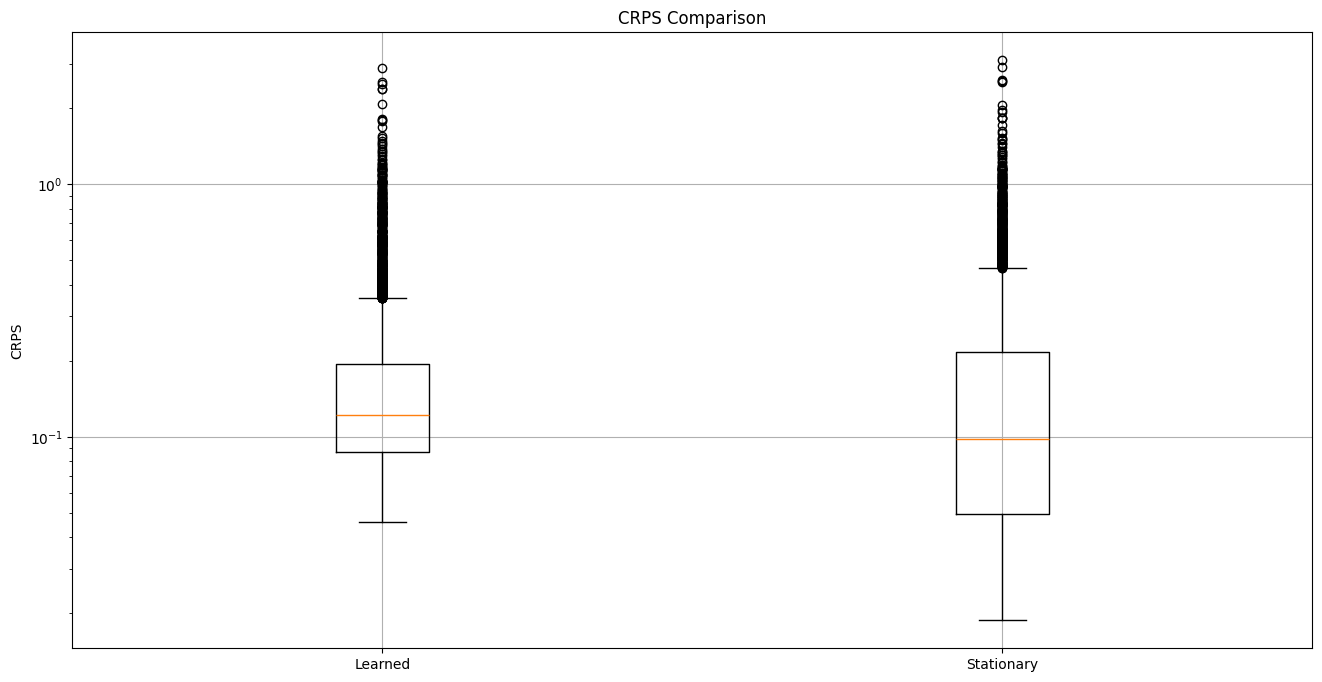

Evaluation finished.


In [10]:
data_test_new_realization(trained_flow, trained_gp, trained_likelihood, naive_gp_model, naive_likelihood,common_data, realization)

## Predictions

In [17]:
learned_pred_2d, guessed_pred_2d, learned_var_2d, guessed_var_2d = data_pred_new_realization(trained_flow, trained_gp, trained_likelihood, naive_gp_model, naive_likelihood, common_data, realization)


--- Testing with Existing Test Grid ---
Using the initial test grid data from generation...
Predicting and Sampling from Learned GP on test grid...


KeyError: 0

In [ ]:
# Ajout des résultats dans df_grid
df_grid['learned_pred'] = learned_pred_2d
df_grid['learned_var'] = learned_var_2d
df_grid['guessed_pred'] = guessed_pred_2d
df_grid['guessed_var'] = guessed_var_2d

df_grid.head()

In [ ]:
df_grid.to_csv("../data/df_grid.csv", index=False)

In [13]:
import importlib
importlib.reload(DKL.utils.display)

NameError: name 'DKL' is not defined